# Klasyfikacja emocji z bazy RAVDESS: MFCC -> HMM -> LDA / Gradient Boosting

Notebook realizuje wymagany pipeline:

**MFCC -> 4 modele HMM -> cechy log-likelihood -> klasyfikator końcowy -> walidacja krzyżowa**

Analizowane emocje:
- **neutralny**
- **radość**
- **smutek**
- **złość**

Uwzględniono wymagania z `notes.txt`:
- walidacja krzyżowa z **20% testu** w każdym podziale,
- pełny pipeline wykonywany osobno w każdym foldzie, bez przecieku danych.


In [21]:
# Jeśli uruchamiasz notebook w nowym środowisku i brakuje bibliotek,
# odkomentuj poniższą komórkę:
#
# !pip install numpy pandas matplotlib librosa scikit-learn hmmlearn soundfile


## 1. Import bibliotek


In [22]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
from hmmlearn.hmm import GaussianHMM
from IPython.display import display

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


## 2. Konfiguracja


In [23]:
def detect_dataset_dir():
    candidates = [
        Path("./Ravdess"),
        Path("./ravdess"),
        Path("./polish_ravdess"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Nie znaleziono katalogu z danymi. Oczekiwano np. ./Ravdess")


DATASET_DIR = detect_dataset_dir()

SAMPLE_RATE = 16000
N_MFCC = 13
N_FFT = 2048
HOP_LENGTH = 512
WIN_LENGTH = 1024

HMM_STATES_LIST = [4, 6, 8]
HMM_COVARIANCE_TYPE = "diag"
HMM_N_ITER = 80
HMM_RANDOM_STATE = 42

N_SPLITS = 5
TEST_SIZE = 0.2
CV_RANDOM_STATE = 42

# Ustaw na True, jeśli chcesz szybciej sprawdzić, czy notebook działa.
SMOKE_TEST_MODE = False

ADD_DERIVED_FEATURES = True
AUDIO_EXTENSIONS = {".wav", ".flac", ".mp3", ".ogg", ".m4a"}
TARGET_EMOTIONS = ["neutralny", "radość", "smutek", "złość"]

if SMOKE_TEST_MODE:
    HMM_STATES_LIST = [4]
    HMM_N_ITER = 10
    N_SPLITS = 2

print("DATASET_DIR =", DATASET_DIR.resolve())


DATASET_DIR = /home/ezdies/SignalBioAI/Lab5/Ravdess


## 3. Mapowanie etykiet emocji


In [24]:
EMOTION_ALIASES = {
    "neutralny": {"neutralny", "neutral", "neutralna", "neutralne", "01", "1"},
    "radość": {"radość", "radosc", "joy", "happy", "happiness", "szczęście", "szczescie", "03", "3"},
    "smutek": {"smutek", "sad", "sadness", "04", "4"},
    "złość": {"złość", "zlosc", "angry", "anger", "gniew", "05", "5"},
}

RAVDESS_CODE_MAP = {
    "01": "neutralny",
    "03": "radość",
    "04": "smutek",
    "05": "złość",
}


def normalize_text(text: str) -> str:
    text = text.lower()
    replacements = {
        "ą": "a", "ć": "c", "ę": "e", "ł": "l",
        "ń": "n", "ó": "o", "ś": "s", "ż": "z", "ź": "z",
    }
    for src, dst in replacements.items():
        text = text.replace(src, dst)
    return text


TEXT_EMOTION_ALIASES = {
    canonical: {normalize_text(alias) for alias in aliases if not alias.isdigit()}
    for canonical, aliases in EMOTION_ALIASES.items()
}


def infer_emotion_label(path: Path):
    stem = normalize_text(path.stem)
    segments = re.split(r"[-_]", path.stem)
    if len(segments) >= 3 and segments[2] in RAVDESS_CODE_MAP:
        return RAVDESS_CODE_MAP[segments[2]]

    for canonical, norm_aliases in TEXT_EMOTION_ALIASES.items():
        tokens = re.split(r"[^a-z0-9]+", stem)
        if any(token in norm_aliases for token in tokens if token):
            return canonical
        if stem in norm_aliases:
            return canonical

    parts = [normalize_text(part) for part in path.parts]
    for canonical, norm_aliases in TEXT_EMOTION_ALIASES.items():
        for part in parts:
            tokens = re.split(r"[^a-z0-9]+", part)
            if any(token in norm_aliases for token in tokens if token):
                return canonical
            if part in norm_aliases:
                return canonical

    return None


## 4. Wczytanie plików i usunięcie duplikatów


In [25]:
def list_audio_files(dataset_dir: Path):
    audio_files = [
        path for path in dataset_dir.rglob("*")
        if path.is_file() and path.suffix.lower() in AUDIO_EXTENSIONS
    ]
    if not audio_files:
        raise FileNotFoundError(f"Nie znaleziono plików audio w {dataset_dir.resolve()}")
    return sorted(audio_files)


def choose_canonical_files(audio_files):
    # W katalogu Ravdess te same nagrania występują podwójnie:
    # bezpośrednio w Actor_* oraz dodatkowo w audio_speech_actors_01-24/Actor_*.
    # Deduplikujemy po nazwie pliku i wybieramy krótszą ścieżkę.
    grouped = {}
    for path in audio_files:
        key = path.name
        grouped.setdefault(key, []).append(path)

    canonical = []
    duplicates = []
    for paths in grouped.values():
        paths = sorted(paths, key=lambda p: (len(p.parts), str(p)))
        canonical.append(paths[0])
        duplicates.extend(paths[1:])

    return sorted(canonical), sorted(duplicates)


def build_metadata_table(audio_files):
    rows = []
    skipped = []
    for path in audio_files:
        emotion = infer_emotion_label(path)
        if emotion in TARGET_EMOTIONS:
            rows.append({
                "path": str(path),
                "filename": path.name,
                "emotion": emotion,
            })
        else:
            skipped.append(str(path))
    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("Nie udało się rozpoznać żadnych plików z docelowych klas.")
    return df, skipped


all_audio_files = list_audio_files(DATASET_DIR)
audio_files, duplicate_files = choose_canonical_files(all_audio_files)
metadata_df, skipped_files = build_metadata_table(audio_files)

print(f"Wszystkie znalezione pliki audio: {len(all_audio_files)}")
print(f"Unikalne nagrania po deduplikacji: {len(audio_files)}")
print(f"Wykryte duplikaty: {len(duplicate_files)}")
print(f"Pliki pominięte po mapowaniu etykiet: {len(skipped_files)}")

display(metadata_df.head())
display(metadata_df["emotion"].value_counts().reindex(TARGET_EMOTIONS).rename_axis("emotion").reset_index(name="count"))


Wszystkie znalezione pliki audio: 2880
Unikalne nagrania po deduplikacji: 1440
Wykryte duplikaty: 1440
Pliki pominięte po mapowaniu etykiet: 768


,path,filename,emotion
0,Ravdess/Actor_01/03-01-01-01-01-01-01.wav,03-01-01-01-01-01-01.wav,neutralny
1,Ravdess/Actor_01/03-01-01-01-01-02-01.wav,03-01-01-01-01-02-01.wav,neutralny
2,Ravdess/Actor_01/03-01-01-01-02-01-01.wav,03-01-01-01-02-01-01.wav,neutralny
3,Ravdess/Actor_01/03-01-01-01-02-02-01.wav,03-01-01-01-02-02-01.wav,neutralny
4,Ravdess/Actor_01/03-01-03-01-01-01-01.wav,03-01-03-01-01-01-01.wav,radość


,emotion,count
0,neutralny,96
1,radość,192
2,smutek,192
3,złość,192


## 5. Ekstrakcja MFCC


In [26]:
def extract_mfcc_sequence(
    file_path,
    sample_rate=SAMPLE_RATE,
    n_mfcc=N_MFCC,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    win_length=WIN_LENGTH,
):
    y, sr = librosa.load(file_path, sr=sample_rate, mono=True)
    if y is None or len(y) == 0:
        raise ValueError(f"Pusty sygnał audio: {file_path}")

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
    )
    mfcc = mfcc.T.astype(np.float64)
    if mfcc.ndim != 2 or mfcc.shape[0] == 0:
        raise ValueError(f"Niepoprawny kształt MFCC dla pliku: {file_path}")
    return mfcc


def load_all_mfcc_sequences(metadata):
    sequences = []
    valid_rows = []
    failed = []

    for _, row in metadata.iterrows():
        try:
            mfcc_seq = extract_mfcc_sequence(row["path"])
            sequences.append(mfcc_seq)
            valid_rows.append({
                "path": row["path"],
                "filename": row["filename"],
                "emotion": row["emotion"],
                "n_frames": mfcc_seq.shape[0],
                "n_features": mfcc_seq.shape[1],
            })
        except Exception as exc:
            failed.append((row["path"], str(exc)))

    seq_df = pd.DataFrame(valid_rows)
    if seq_df.empty:
        raise ValueError("Nie udało się wyekstrahować MFCC z żadnego pliku.")
    return sequences, seq_df, failed


sequences, sequence_info_df, failed_files = load_all_mfcc_sequences(metadata_df)
print(f"Poprawnie przetworzone nagrania: {len(sequences)}")
print(f"Błędy ekstrakcji: {len(failed_files)}")
display(sequence_info_df.head())


Poprawnie przetworzone nagrania: 672
Błędy ekstrakcji: 0


,path,filename,emotion,n_frames,n_features
0,Ravdess/Actor_01/03-01-01-01-01-01-01.wav,03-01-01-01-01-01-01.wav,neutralny,104,13
1,Ravdess/Actor_01/03-01-01-01-01-02-01.wav,03-01-01-01-01-02-01.wav,neutralny,105,13
2,Ravdess/Actor_01/03-01-01-01-02-01-01.wav,03-01-01-01-02-01-01.wav,neutralny,103,13
3,Ravdess/Actor_01/03-01-01-01-02-02-01.wav,03-01-01-01-02-02-01.wav,neutralny,100,13
4,Ravdess/Actor_01/03-01-03-01-01-01-01.wav,03-01-03-01-01-01-01.wav,radość,109,13


## 6. Przygotowanie danych


In [27]:
data_df = sequence_info_df.copy()
data_df["sequence_id"] = np.arange(len(data_df))
data_df = data_df[["sequence_id", "path", "filename", "emotion", "n_frames", "n_features"]].reset_index(drop=True)

label_to_id = {label: idx for idx, label in enumerate(TARGET_EMOTIONS)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

y = data_df["emotion"].map(label_to_id).values
X_sequences = sequences

display(data_df.head())
print("Mapowanie etykiet:", label_to_id)


,sequence_id,path,filename,emotion,n_frames,n_features
0,0,Ravdess/Actor_01/03-01-01-01-01-01-01.wav,03-01-01-01-01-01-01.wav,neutralny,104,13
1,1,Ravdess/Actor_01/03-01-01-01-01-02-01.wav,03-01-01-01-01-02-01.wav,neutralny,105,13
2,2,Ravdess/Actor_01/03-01-01-01-02-01-01.wav,03-01-01-01-02-01-01.wav,neutralny,103,13
3,3,Ravdess/Actor_01/03-01-01-01-02-02-01.wav,03-01-01-01-02-02-01.wav,neutralny,100,13
4,4,Ravdess/Actor_01/03-01-03-01-01-01-01.wav,03-01-03-01-01-01-01.wav,radość,109,13


Mapowanie etykiet: {'neutralny': 0, 'radość': 1, 'smutek': 2, 'złość': 3}


## 7. Funkcje pomocnicze dla HMM i cech log-likelihood


In [28]:
def stack_sequences(sequence_list):
    lengths = [seq.shape[0] for seq in sequence_list]
    x_concat = np.vstack(sequence_list)
    return x_concat, lengths


def fit_hmm_for_class(sequence_list, n_states, covariance_type="diag", n_iter=200, random_state=42):
    x_concat, lengths = stack_sequences(sequence_list)
    model = GaussianHMM(
        n_components=n_states,
        covariance_type=covariance_type,
        n_iter=n_iter,
        random_state=random_state,
        verbose=False,
    )
    model.fit(x_concat, lengths)
    return model


def fit_class_hmms(train_sequences, train_labels, n_states):
    class_models = {}
    for label in TARGET_EMOTIONS:
        class_id = label_to_id[label]
        class_sequences = [seq for seq, y_i in zip(train_sequences, train_labels) if y_i == class_id]
        if not class_sequences:
            raise ValueError(f"Brak sekwencji treningowych dla klasy {label}")
        class_models[label] = fit_hmm_for_class(
            class_sequences,
            n_states=n_states,
            covariance_type=HMM_COVARIANCE_TYPE,
            n_iter=HMM_N_ITER,
            random_state=HMM_RANDOM_STATE,
        )
    return class_models


def safe_hmm_score(model, sequence):
    try:
        return float(model.score(sequence))
    except Exception:
        return -1e12


def build_loglikelihood_features(sequence_list, class_models, add_derived_features=True):
    base_features = []
    for seq in sequence_list:
        scores = [safe_hmm_score(class_models[label], seq) for label in TARGET_EMOTIONS]
        base_features.append(scores)

    x_base = np.array(base_features, dtype=np.float64)
    if not add_derived_features:
        return x_base

    row_max = x_base.max(axis=1, keepdims=True)
    row_min = x_base.min(axis=1, keepdims=True)
    row_mean = x_base.mean(axis=1, keepdims=True)
    row_std = x_base.std(axis=1, keepdims=True)

    sorted_scores = np.sort(x_base, axis=1)
    best = sorted_scores[:, -1].reshape(-1, 1)
    second_best = sorted_scores[:, -2].reshape(-1, 1)
    margin = best - second_best

    denom = np.where(row_std == 0, 1.0, row_std)
    zscores = (x_base - row_mean) / denom

    return np.hstack([
        x_base,
        row_max,
        row_min,
        row_mean,
        row_std,
        margin,
        zscores,
    ])


def get_classifier(classifier_name):
    if classifier_name == "LDA":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearDiscriminantAnalysis()),
        ])
    if classifier_name == "GradientBoosting":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", GradientBoostingClassifier(random_state=42)),
        ])
    raise ValueError(f"Nieznany klasyfikator: {classifier_name}")


def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "abs_mcc": abs(matthews_corrcoef(y_true, y_pred)),
    }


## 8. Walidacja krzyżowa pełnego pipeline'u


In [29]:
def run_cv_experiment(
    sequences,
    labels,
    n_states,
    classifier_names,
    n_splits=N_SPLITS,
    test_size=TEST_SIZE,
    random_state=CV_RANDOM_STATE,
):
    sss = StratifiedShuffleSplit(
        n_splits=n_splits,
        test_size=test_size,
        random_state=random_state,
    )

    fold_rows_by_classifier = {name: [] for name in classifier_names}
    all_true_by_classifier = {name: [] for name in classifier_names}
    all_pred_by_classifier = {name: [] for name in classifier_names}
    fold_confusions_by_classifier = {name: [] for name in classifier_names}

    for fold_idx, (train_idx, test_idx) in enumerate(sss.split(np.zeros(len(labels)), labels), start=1):
        print(f"  Fold {fold_idx}/{n_splits} for HMM states={n_states}")
        x_train_seq = [sequences[i] for i in train_idx]
        y_train = labels[train_idx]
        x_test_seq = [sequences[i] for i in test_idx]
        y_test = labels[test_idx]

        print("    Trening modeli HMM...")
        class_models = fit_class_hmms(x_train_seq, y_train, n_states=n_states)

        print("    Budowa cech log-likelihood...")
        x_train_feat = build_loglikelihood_features(
            x_train_seq,
            class_models,
            add_derived_features=ADD_DERIVED_FEATURES,
        )
        x_test_feat = build_loglikelihood_features(
            x_test_seq,
            class_models,
            add_derived_features=ADD_DERIVED_FEATURES,
        )

        for classifier_name in classifier_names:
            print(f"    Klasyfikacja: {classifier_name}")
            clf = get_classifier(classifier_name)
            clf.fit(x_train_feat, y_train)
            y_pred = clf.predict(x_test_feat)

            metrics = compute_metrics(y_test, y_pred)
            fold_rows_by_classifier[classifier_name].append({
                "hmm_states": n_states,
                "classifier": classifier_name,
                "fold": fold_idx,
                **metrics,
            })

            all_true_by_classifier[classifier_name].extend(y_test.tolist())
            all_pred_by_classifier[classifier_name].extend(y_pred.tolist())
            fold_confusions_by_classifier[classifier_name].append(
                confusion_matrix(y_test, y_pred, labels=list(range(len(TARGET_EMOTIONS))))
            )

    summaries = []
    for classifier_name in classifier_names:
        fold_df = pd.DataFrame(fold_rows_by_classifier[classifier_name])
        summaries.append({
            "hmm_states": n_states,
            "classifier": classifier_name,
            "accuracy_mean": fold_df["accuracy"].mean(),
            "accuracy_std": fold_df["accuracy"].std(ddof=1) if len(fold_df) > 1 else 0.0,
            "precision_macro_mean": fold_df["precision_macro"].mean(),
            "precision_macro_std": fold_df["precision_macro"].std(ddof=1) if len(fold_df) > 1 else 0.0,
            "recall_macro_mean": fold_df["recall_macro"].mean(),
            "recall_macro_std": fold_df["recall_macro"].std(ddof=1) if len(fold_df) > 1 else 0.0,
            "f1_macro_mean": fold_df["f1_macro"].mean(),
            "f1_macro_std": fold_df["f1_macro"].std(ddof=1) if len(fold_df) > 1 else 0.0,
            "abs_mcc_mean": fold_df["abs_mcc"].mean(),
            "abs_mcc_std": fold_df["abs_mcc"].std(ddof=1) if len(fold_df) > 1 else 0.0,
            "confusion_matrix": np.sum(fold_confusions_by_classifier[classifier_name], axis=0),
            "all_true": np.array(all_true_by_classifier[classifier_name]),
            "all_pred": np.array(all_pred_by_classifier[classifier_name]),
            "fold_metrics": fold_df,
        })
    return summaries


## 9. Uruchomienie eksperymentów dla 3 konfiguracji HMM


In [30]:
all_summaries = []
all_fold_tables = []

for n_states in HMM_STATES_LIST:
    print(f"Uruchamianie eksperymentu dla HMM states={n_states}")
    summaries = run_cv_experiment(
        sequences=X_sequences,
        labels=y,
        n_states=n_states,
        classifier_names=["LDA", "GradientBoosting"],
        n_splits=N_SPLITS,
        test_size=TEST_SIZE,
        random_state=CV_RANDOM_STATE,
    )
    for summary in summaries:
        all_summaries.append(summary)
        all_fold_tables.append(summary["fold_metrics"])

print("Gotowe.")


Uruchamianie eksperymentu dla HMM states=4
  Fold 1/5 for HMM states=4
    Trening modeli HMM...
    Budowa cech log-likelihood...
    Klasyfikacja: LDA
    Klasyfikacja: GradientBoosting
  Fold 2/5 for HMM states=4
    Trening modeli HMM...
    Budowa cech log-likelihood...
    Klasyfikacja: LDA
    Klasyfikacja: GradientBoosting
  Fold 3/5 for HMM states=4
    Trening modeli HMM...
    Budowa cech log-likelihood...
    Klasyfikacja: LDA
    Klasyfikacja: GradientBoosting
  Fold 4/5 for HMM states=4
    Trening modeli HMM...
    Budowa cech log-likelihood...
    Klasyfikacja: LDA
    Klasyfikacja: GradientBoosting
  Fold 5/5 for HMM states=4
    Trening modeli HMM...
    Budowa cech log-likelihood...
    Klasyfikacja: LDA
    Klasyfikacja: GradientBoosting
Uruchamianie eksperymentu dla HMM states=6
  Fold 1/5 for HMM states=6
    Trening modeli HMM...
    Budowa cech log-likelihood...
    Klasyfikacja: LDA
    Klasyfikacja: GradientBoosting
  Fold 2/5 for HMM states=6
    Trening mode

## 10. Tabela wyników zbiorczych


In [31]:
results_df = pd.DataFrame([
    {
        "HMM states": s["hmm_states"],
        "Classifier": s["classifier"],
        "Accuracy mean": s["accuracy_mean"],
        "Accuracy std": s["accuracy_std"],
        "Precision macro mean": s["precision_macro_mean"],
        "Precision macro std": s["precision_macro_std"],
        "Recall macro mean": s["recall_macro_mean"],
        "Recall macro std": s["recall_macro_std"],
        "F1 macro mean": s["f1_macro_mean"],
        "F1 macro std": s["f1_macro_std"],
        "abs(MCC) mean": s["abs_mcc_mean"],
        "abs(MCC) std": s["abs_mcc_std"],
    }
    for s in all_summaries
]).sort_values(by=["F1 macro mean", "Accuracy mean", "abs(MCC) mean"], ascending=False).reset_index(drop=True)

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
display(results_df)


,HMM states,Classifier,Accuracy mean,Accuracy std,Precision macro mean,Precision macro std,Recall macro mean,Recall macro std,F1 macro mean,F1 macro std,abs(MCC) mean,abs(MCC) std
0,6,GradientBoosting,0.5407,0.0367,0.5407,0.0372,0.5323,0.0375,0.5346,0.0377,0.3744,0.0493
1,8,GradientBoosting,0.5244,0.0169,0.5228,0.0277,0.5154,0.0147,0.5151,0.0190,0.3545,0.0220
2,8,LDA,0.5200,0.0657,0.5227,0.0589,0.5062,0.0574,0.5088,0.0590,0.3491,0.0870
3,4,GradientBoosting,0.5185,0.0526,0.5059,0.0595,0.4981,0.0586,0.4994,0.0583,0.3440,0.0731
4,6,LDA,0.5052,0.0498,0.5110,0.0455,0.4985,0.0512,0.4990,0.0499,0.3305,0.0673
5,4,LDA,0.4963,0.0441,0.5028,0.0455,0.4866,0.0399,0.4897,0.0430,0.3175,0.0578


## 11. Metryki per fold


In [32]:
fold_results_df = pd.concat(all_fold_tables, ignore_index=True)
display(fold_results_df)


,hmm_states,classifier,fold,accuracy,precision_macro,recall_macro,f1_macro,abs_mcc
0,4,LDA,1,0.4889,0.4979,0.4739,0.4794,0.3059
1,4,LDA,2,0.4963,0.4920,0.4732,0.4788,0.3157
2,4,LDA,3,0.4593,0.4814,0.4678,0.4656,0.2719
3,4,LDA,4,0.5704,0.5805,0.5574,0.5650,0.4155
4,4,LDA,5,0.4667,0.4621,0.4610,0.4596,0.2783
5,4,GradientBoosting,1,0.5259,0.5348,0.5194,0.5241,0.3550
6,4,GradientBoosting,2,0.5630,0.5409,0.5442,0.5410,0.4095
7,4,GradientBoosting,3,0.4889,0.4650,0.4610,0.4604,0.3030
8,4,GradientBoosting,4,0.5704,0.5657,0.5513,0.5543,0.4118
9,4,GradientBoosting,5,0.4444,0.4230,0.4148,0.4173,0.2406


## 12. Wybór najlepszej konfiguracji


In [33]:
best_idx = results_df["F1 macro mean"].idxmax()
best_row = results_df.loc[best_idx]

print("Najlepsza konfiguracja wg średniego F1 macro:")
display(best_row.to_frame(name="value"))

best_summary = None
for summary in all_summaries:
    if summary["hmm_states"] == best_row["HMM states"] and summary["classifier"] == best_row["Classifier"]:
        best_summary = summary
        break

assert best_summary is not None


Najlepsza konfiguracja wg średniego F1 macro:


,value
HMM states,6
Classifier,GradientBoosting
Accuracy mean,0.5407
Accuracy std,0.0367
Precision macro mean,0.5407
Precision macro std,0.0372
Recall macro mean,0.5323
Recall macro std,0.0375
F1 macro mean,0.5346
F1 macro std,0.0377


## 13. Wizualizacje porównawcze


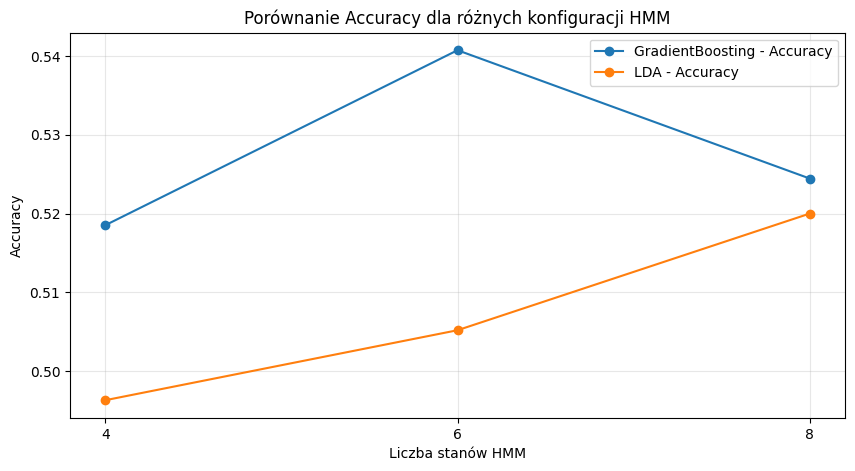

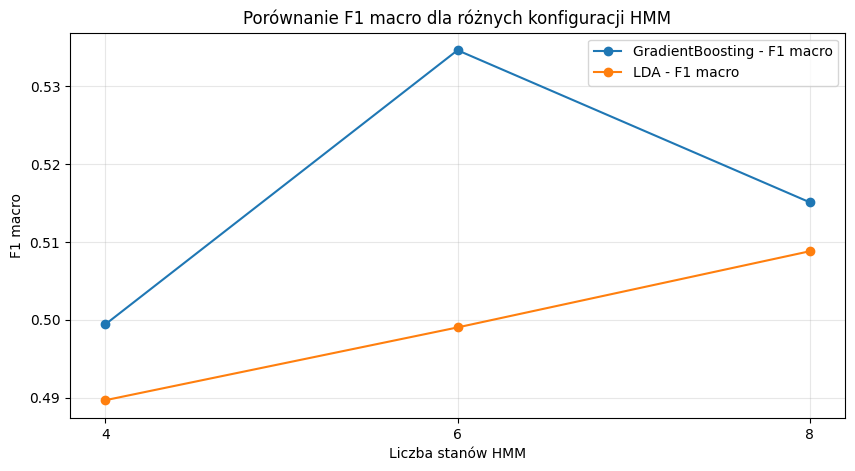

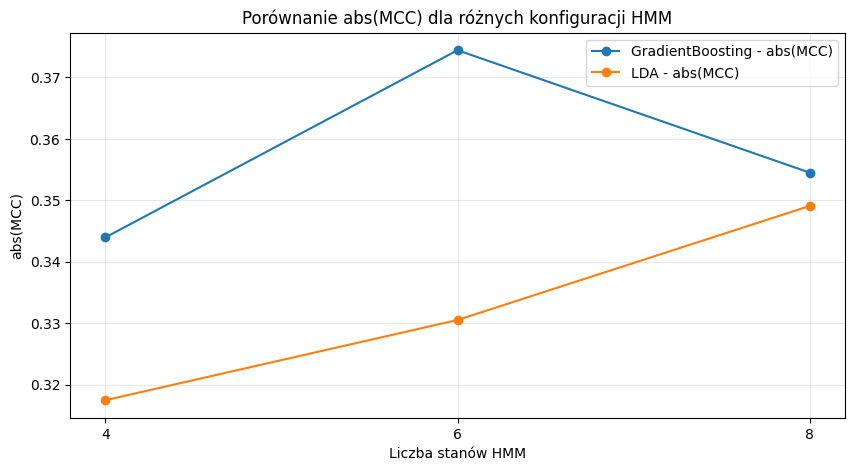

In [34]:
plot_df = results_df.copy()

plt.figure(figsize=(10, 5))
for classifier_name in plot_df["Classifier"].unique():
    subset = plot_df[plot_df["Classifier"] == classifier_name].sort_values("HMM states")
    plt.plot(subset["HMM states"], subset["Accuracy mean"], marker="o", label=f"{classifier_name} - Accuracy")
plt.xlabel("Liczba stanów HMM")
plt.ylabel("Accuracy")
plt.title("Porównanie Accuracy dla różnych konfiguracji HMM")
plt.xticks(HMM_STATES_LIST)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
for classifier_name in plot_df["Classifier"].unique():
    subset = plot_df[plot_df["Classifier"] == classifier_name].sort_values("HMM states")
    plt.plot(subset["HMM states"], subset["F1 macro mean"], marker="o", label=f"{classifier_name} - F1 macro")
plt.xlabel("Liczba stanów HMM")
plt.ylabel("F1 macro")
plt.title("Porównanie F1 macro dla różnych konfiguracji HMM")
plt.xticks(HMM_STATES_LIST)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
for classifier_name in plot_df["Classifier"].unique():
    subset = plot_df[plot_df["Classifier"] == classifier_name].sort_values("HMM states")
    plt.plot(subset["HMM states"], subset["abs(MCC) mean"], marker="o", label=f"{classifier_name} - abs(MCC)")
plt.xlabel("Liczba stanów HMM")
plt.ylabel("abs(MCC)")
plt.title("Porównanie abs(MCC) dla różnych konfiguracji HMM")
plt.xticks(HMM_STATES_LIST)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 14. Macierz pomyłek dla najlepszej konfiguracji


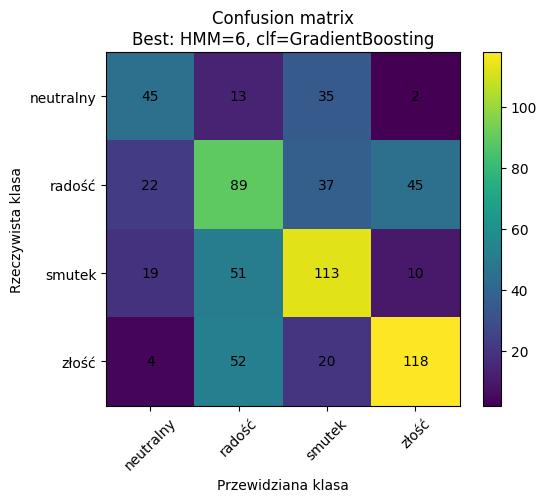

Raport klasyfikacji dla zsumowanych predykcji z foldów:
              precision    recall  f1-score   support

   neutralny       0.50      0.47      0.49        95
      radość       0.43      0.46      0.45       193
      smutek       0.55      0.59      0.57       193
       złość       0.67      0.61      0.64       194

    accuracy                           0.54       675
   macro avg       0.54      0.53      0.54       675
weighted avg       0.55      0.54      0.54       675



In [35]:
best_cm = best_summary["confusion_matrix"]

plt.figure(figsize=(6, 5))
plt.imshow(best_cm, interpolation="nearest")
plt.title(f"Confusion matrix\nBest: HMM={best_summary['hmm_states']}, clf={best_summary['classifier']}")
plt.colorbar()
tick_marks = np.arange(len(TARGET_EMOTIONS))
plt.xticks(tick_marks, TARGET_EMOTIONS, rotation=45)
plt.yticks(tick_marks, TARGET_EMOTIONS)

for i in range(best_cm.shape[0]):
    for j in range(best_cm.shape[1]):
        plt.text(j, i, format(best_cm[i, j], "d"), ha="center", va="center")

plt.ylabel("Rzeczywista klasa")
plt.xlabel("Przewidziana klasa")
plt.tight_layout()
plt.show()

print("Raport klasyfikacji dla zsumowanych predykcji z foldów:")
print(
    classification_report(
        best_summary["all_true"],
        best_summary["all_pred"],
        target_names=TARGET_EMOTIONS,
        zero_division=0,
    )
)


## 15. Tabela końcowa do sprawozdania


In [36]:
final_report_df = results_df[[
    "HMM states",
    "Classifier",
    "Accuracy mean",
    "Precision macro mean",
    "Recall macro mean",
    "F1 macro mean",
    "abs(MCC) mean",
    "Accuracy std",
    "Precision macro std",
    "Recall macro std",
    "F1 macro std",
    "abs(MCC) std",
]].copy()

display(final_report_df)
final_report_df.to_csv("hmm_emotion_classification_results.csv", index=False)
print("Zapisano tabelę wyników do pliku: hmm_emotion_classification_results.csv")


,HMM states,Classifier,Accuracy mean,Precision macro mean,Recall macro mean,F1 macro mean,abs(MCC) mean,Accuracy std,Precision macro std,Recall macro std,F1 macro std,abs(MCC) std
0,6,GradientBoosting,0.5407,0.5407,0.5323,0.5346,0.3744,0.0367,0.0372,0.0375,0.0377,0.0493
1,8,GradientBoosting,0.5244,0.5228,0.5154,0.5151,0.3545,0.0169,0.0277,0.0147,0.0190,0.0220
2,8,LDA,0.5200,0.5227,0.5062,0.5088,0.3491,0.0657,0.0589,0.0574,0.0590,0.0870
3,4,GradientBoosting,0.5185,0.5059,0.4981,0.4994,0.3440,0.0526,0.0595,0.0586,0.0583,0.0731
4,6,LDA,0.5052,0.5110,0.4985,0.4990,0.3305,0.0498,0.0455,0.0512,0.0499,0.0673
5,4,LDA,0.4963,0.5028,0.4866,0.4897,0.3175,0.0441,0.0455,0.0399,0.0430,0.0578


Zapisano tabelę wyników do pliku: hmm_emotion_classification_results.csv


## 16. Wnioski końcowe


In [37]:
best_states = int(best_row["HMM states"])
best_classifier = best_row["Classifier"]

avg_by_classifier = (
    results_df.groupby("Classifier")[["Accuracy mean", "F1 macro mean", "abs(MCC) mean"]]
    .mean()
    .sort_values(by=["F1 macro mean", "Accuracy mean", "abs(MCC) mean"], ascending=False)
)

print(f"Najlepsza liczba stanów HMM: {best_states}")
print(f"Najlepszy klasyfikator końcowy: {best_classifier}")
print("\nŚrednie wyniki zagregowane po klasyfikatorze:")
display(avg_by_classifier)

best_accuracy = float(best_row["Accuracy mean"])
best_precision = float(best_row["Precision macro mean"])
best_recall = float(best_row["Recall macro mean"])
best_f1 = float(best_row["F1 macro mean"])
best_mcc = float(best_row["abs(MCC) mean"])

classifier_means = (
    results_df.groupby("Classifier")[["Accuracy mean", "F1 macro mean", "abs(MCC) mean"]]
    .mean()
    .sort_values(by=["F1 macro mean", "Accuracy mean", "abs(MCC) mean"], ascending=False)
)
best_classifier_global = classifier_means.index[0]

print("\nWnioski końcowe do sprawozdania:")
print(
    f"1. Najlepszą konfiguracją okazał się model z {best_states} stanami HMM "
    f"oraz klasyfikatorem {best_classifier}."
)
print(
    f"   Dla tej konfiguracji uzyskano średnio: accuracy={best_accuracy:.4f}, "
    f"precision macro={best_precision:.4f}, recall macro={best_recall:.4f}, "
    f"F1 macro={best_f1:.4f}, abs(MCC)={best_mcc:.4f}."
)
print(
    f"2. Najlepszy końcowy klasyfikator w całym porównaniu to {best_classifier_global}, "
    "co wynika z wyższych średnich wartości F1 macro oraz abs(MCC)."
)
print(
    "3. Cechy log-likelihood wyznaczone na podstawie 4 modeli HMM okazały się użyteczne, "
    "ponieważ pozwoliły zbudować działający klasyfikator czterech emocji na bazie walidacji krzyżowej."
)
print(
    "4. Ograniczenia podejścia: wykorzystano wyłącznie MFCC, HMM są wrażliwe na liczbę stanów "
    "i inicjalizację, a część informacji emocjonalnej może nie być dobrze opisana przez same MFCC."
)
print(
    "5. Możliwe usprawnienia: dodanie delta i delta-delta MFCC, strojenie parametrów HMM, "
    "rozszerzenie cech o deskryptory prosodyczne oraz porównanie z dodatkowymi klasyfikatorami."
)


Najlepsza liczba stanów HMM: 6
Najlepszy klasyfikator końcowy: GradientBoosting

Średnie wyniki zagregowane po klasyfikatorze:


,Accuracy mean,F1 macro mean,abs(MCC) mean
Classifier,,,
GradientBoosting,0.5279,0.5164,0.3576
LDA,0.5072,0.4992,0.3324



Wnioski końcowe do sprawozdania:
1. Najlepszą konfiguracją okazał się model z 6 stanami HMM oraz klasyfikatorem GradientBoosting.
   Dla tej konfiguracji uzyskano średnio: accuracy=0.5407, precision macro=0.5407, recall macro=0.5323, F1 macro=0.5346, abs(MCC)=0.3744.
2. Najlepszy końcowy klasyfikator w całym porównaniu to GradientBoosting, co wynika z wyższych średnich wartości F1 macro oraz abs(MCC).
3. Cechy log-likelihood wyznaczone na podstawie 4 modeli HMM okazały się użyteczne, ponieważ pozwoliły zbudować działający klasyfikator czterech emocji na bazie walidacji krzyżowej.
4. Ograniczenia podejścia: wykorzystano wyłącznie MFCC, HMM są wrażliwe na liczbę stanów i inicjalizację, a część informacji emocjonalnej może nie być dobrze opisana przez same MFCC.
5. Możliwe usprawnienia: dodanie delta i delta-delta MFCC, strojenie parametrów HMM, rozszerzenie cech o deskryptory prosodyczne oraz porównanie z dodatkowymi klasyfikatorami.
